In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all 5 files
home         = pd.read_csv('home_page_table.csv')
search       = pd.read_csv('search_page_table.csv')
payment      = pd.read_csv('payment_page_table.csv')
confirmation = pd.read_csv('payment_confirmation_table.csv')
users        = pd.read_csv('user_table.csv', on_bad_lines='skip')

# See columns and first rows of each file
for name, dataframe in [('HOME', home), ('SEARCH', search),
                         ('PAYMENT', payment), ('CONFIRMATION', confirmation),
                         ('USERS', users)]:
    print(f"\n{'='*40}")
    print(f"{name} TABLE")
    print(f"Shape: {dataframe.shape}")
    print(dataframe.head(3))
    print("Columns:", dataframe.columns.tolist())


HOME TABLE
Shape: (90400, 2)
   user_id       page
0   313593  home_page
1   468315  home_page
2   264005  home_page
Columns: ['user_id', 'page']

SEARCH TABLE
Shape: (45200, 2)
   user_id         page
0    15866  search_page
1   347058  search_page
2   577020  search_page
Columns: ['user_id', 'page']

PAYMENT TABLE
Shape: (6030, 2)
   user_id          page
0   253019  payment_page
1   310478  payment_page
2   304081  payment_page
Columns: ['user_id', 'page']

CONFIRMATION TABLE
Shape: (452, 2)
   user_id                       page
0   123100  payment_confirmation_page
1   704999  payment_confirmation_page
2   407188  payment_confirmation_page
Columns: ['user_id', 'page']

USERS TABLE
Shape: (90400, 4)
   user_id        date   device     sex
0   450007  2015-02-28  Desktop  Female
1   756838  2015-01-13  Desktop    Male
2   568983  2015-04-09  Desktop    Male
Columns: ['user_id', 'date', 'device', 'sex']


In [ ]:
for name, dataframe in [('HOME', home), ('SEARCH', search),
                         ('PAYMENT', payment), ('CONFIRMATION', confirmation),
                         ('USERS', users)]:
    print(f"\n{name} missing values:")
    print(dataframe.isnull().sum())


HOME missing values:
user_id    0
page       0
dtype: int64

SEARCH missing values:
user_id    0
page       0
dtype: int64

PAYMENT missing values:
user_id    0
page       0
dtype: int64

CONFIRMATION missing values:
user_id    0
page       0
dtype: int64

USERS missing values:
user_id    0
date       0
device     0
sex        0
dtype: int64


##Data Cleaning and Feature Engineering

In [ ]:
# Count users at each stage
stage_counts = {
    'Home Page'    : len(home),
    'Search Page'  : len(search),
    'Payment Page' : len(payment),
    'Confirmation' : len(confirmation)
}

funnel_df = pd.DataFrame({
    'Stage' : list(stage_counts.keys()),
    'Users' : list(stage_counts.values())
})

# Calculate drop-off and conversion rates
funnel_df['Previous Users'] = funnel_df['Users'].shift(1)
funnel_df['Drop Off Users'] = funnel_df['Previous Users'] - funnel_df['Users']
funnel_df['Conv Rate %']    = (funnel_df['Users'] / funnel_df['Previous Users'] * 100).round(1)
funnel_df['Overall %']      = (funnel_df['Users'] / funnel_df['Users'].iloc[0] * 100).round(1)

print(funnel_df[['Stage', 'Users', 'Drop Off Users', 'Conv Rate %', 'Overall %']])

          Stage  Users  Drop Off Users  Conv Rate %  Overall %
0     Home Page  90400             NaN          NaN      100.0
1   Search Page  45200         45200.0         50.0       50.0
2  Payment Page   6030         39170.0         13.3        6.7
3  Confirmation    452          5578.0          7.5        0.5


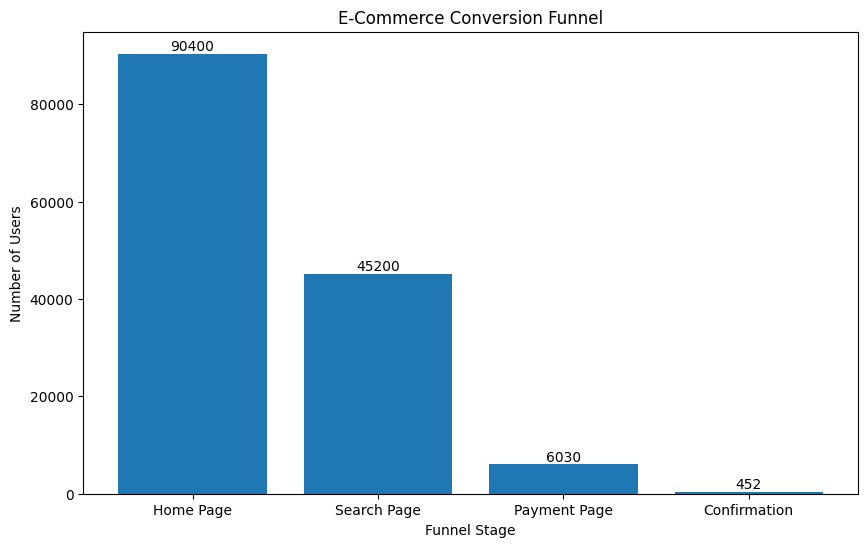

In [ ]:
#Chart1:Funnel Bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bars = plt.bar(
    funnel_df['Stage'],
    funnel_df['Users'],
)

# Add labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height}', # Added the text argument 's'
        ha='center',
        va='bottom'
    )

plt.title('E-Commerce Conversion Funnel')
plt.xlabel('Funnel Stage')
plt.ylabel('Number of Users')

plt.show()

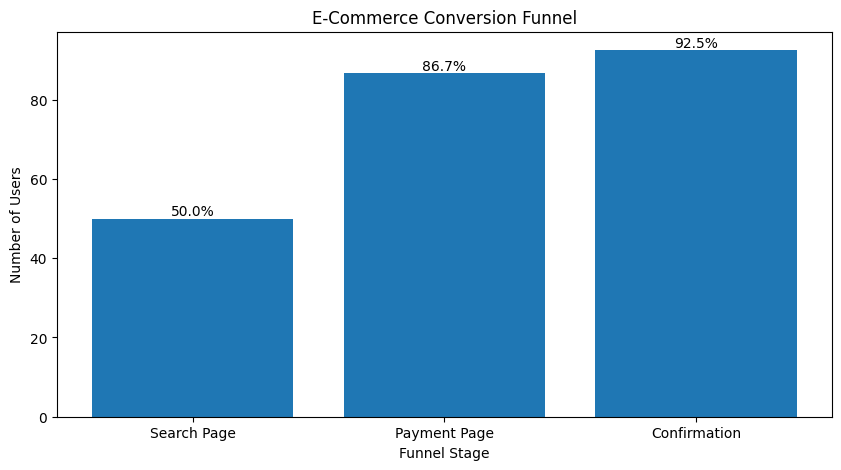

In [ ]:
#Drop-off rate at each stage
dropped_df=funnel_df.dropna().copy()
dropped_df['Drop Off %']=(100-dropped_df['Conv Rate %']).round(1)

plt.figure(figsize=(10,5))

bars=plt.bar(dropped_df['Stage'], dropped_df['Drop Off %'])

for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, height, f'{height}'+'%', ha='center', va='bottom')

plt.title('E-Commerce Conversion Funnel')
plt.xlabel('Funnel Stage')
plt.ylabel('Number of Users')

plt.show()

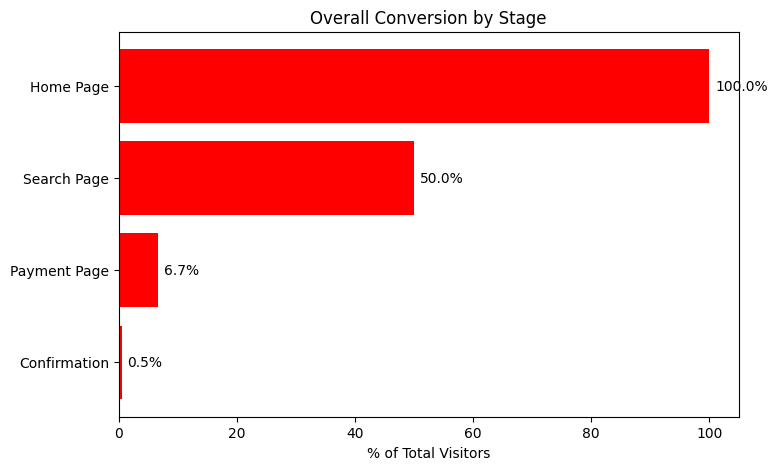

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.barh(funnel_df['Stage'], funnel_df['Overall %'], color='red')

# Add labels
for bar in bars:
    x = bar.get_width()
    y = bar.get_y() + bar.get_height()/2
    plt.text(x + 1, y, f'{x:.1f}%', va='center')

plt.title('Overall Conversion by Stage')
plt.xlabel('% of Total Visitors')

plt.gca().invert_yaxis()
plt.show()

In [ ]:
#Merge with user table for gender analysis
home_users    = home.merge(users, on='user_id', how='left')
search_users  = search.merge(users, on='user_id', how='left')
payment_users = payment.merge(users, on='user_id', how='left')
conf_users    = confirmation.merge(users, on='user_id', how='left')

# Check merge worked
print("Home with gender:", home_users.shape)
print(home_users.head(3))
print("\nGender values:", home_users['sex'].value_counts())

Home with gender: (90400, 5)
   user_id       page        date   device     sex
0   313593  home_page  2015-02-26  Desktop  Female
1   468315  home_page  2015-02-21  Desktop    Male
2   264005  home_page  2015-03-25  Desktop  Female

Gender values: sex
Male      45325
Female    45075
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128105 (\N{WOMAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


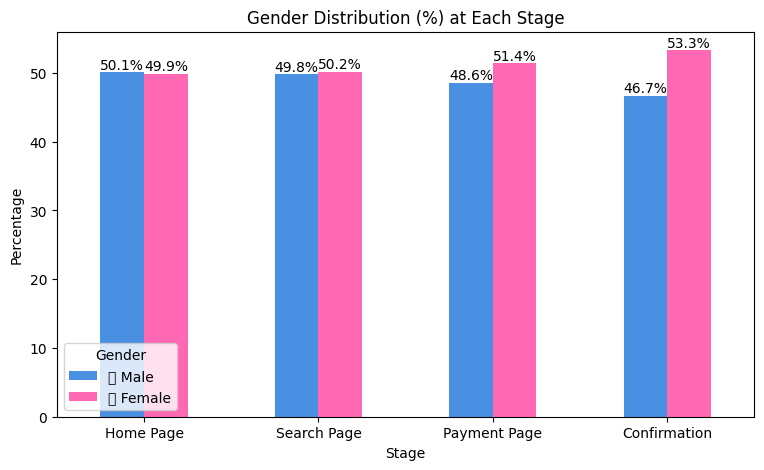

In [ ]:
import matplotlib.pyplot as plt

# Create pivot table directly
gender_pivot = pd.DataFrame({
    '👨 Male': [
        (home_users['sex'] == 'Male').sum(),
        (search_users['sex'] == 'Male').sum(),
        (payment_users['sex'] == 'Male').sum(),
        (conf_users['sex'] == 'Male').sum()
    ],

    '👩 Female': [
        (home_users['sex'] == 'Female').sum(),
        (search_users['sex'] == 'Female').sum(),
        (payment_users['sex'] == 'Female').sum(),
        (conf_users['sex'] == 'Female').sum()
    ]
},

index=['Home Page', 'Search Page', 'Payment Page', 'Confirmation'])

# Plot chart
ax = gender_pivot.plot(
    kind='bar',
    figsize=(9, 5),
    color=['#4A90E2', '#FF69B4']
)

# Add labels on bars
for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom'
    )

plt.title('Users by Gender at Each Stage')
plt.xlabel('Stage')
plt.ylabel('Users')

plt.xticks(rotation=0)
plt.legend(title='Gender')

plt.show()

Male conversion rate   : 0.47%
Female conversion rate : 0.53%


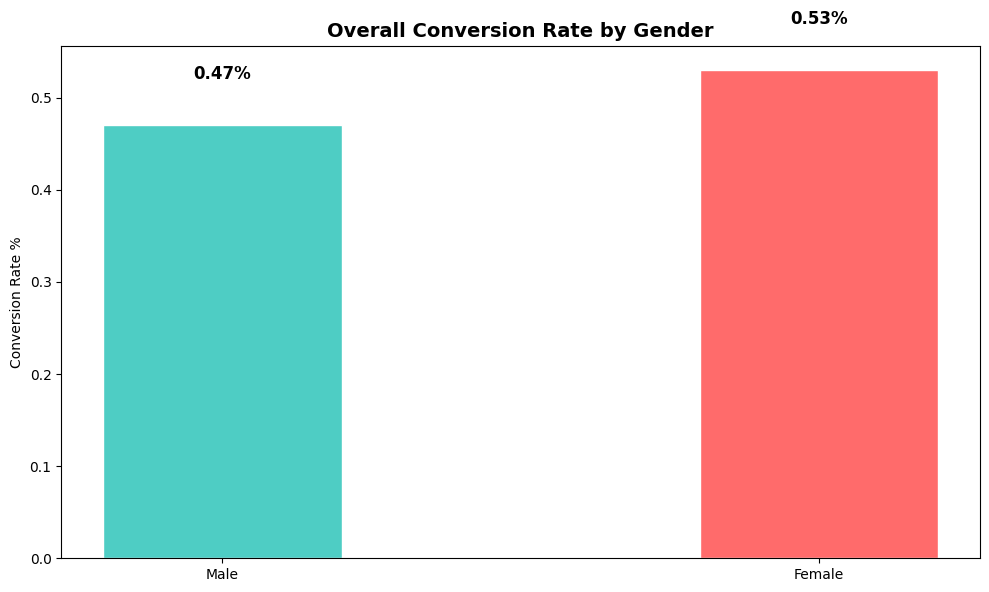

In [ ]:
# Calculate conversion rate for each gender
total_male_visitors   = home_users[home_users['sex'] == 'Male'].shape[0]
total_female_visitors = home_users[home_users['sex'] == 'Female'].shape[0]

male_purchases   = conf_users[conf_users['sex'] == 'Male'].shape[0]
female_purchases = conf_users[conf_users['sex'] == 'Female'].shape[0]

male_conv_rate   = round(male_purchases   / total_male_visitors   * 100, 2)
female_conv_rate = round(female_purchases / total_female_visitors * 100, 2)

print(f"Male conversion rate   : {male_conv_rate}%")
print(f"Female conversion rate : {female_conv_rate}%")

# Bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    ['Male', 'Female'],
    [male_conv_rate, female_conv_rate],
    color=['#4ECDC4', '#FF6B6B'],
    edgecolor='white',
    width=0.4
)

for i, val in enumerate([male_conv_rate, female_conv_rate]):
    plt.text(i, val + 0.05, f'{val}%',
             ha='center', fontsize=12, fontweight='bold')

plt.title('Overall Conversion Rate by Gender',
          fontsize=14, fontweight='bold')
plt.ylabel('Conversion Rate %')
plt.tight_layout()
plt.show()